In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.gridspec import GridSpec

from tqdm import tqdm

from transformers import GPT2LMHeadModel, GPT2Tokenizer, logging
import torch
import torch.nn.functional as F

logging.set_verbosity_error()

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
tokenizer = GPT2Tokenizer.from_pretrained('gpt2')
model = GPT2LMHeadModel.from_pretrained('gpt2').to(device)
#
model.eval()
#
n_embed = model.config.n_embd
n_head = model.config.n_head
n_layer = model.config.n_layer
head_dim = n_embed // n_head

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

# Implant hook to capture the activations from attention heads

In [4]:
layer2change = 100
head2change = 100
ablate = False

def implant_hook(num_layer):
  def hook(module, input):

    # print(f'Input Length: {len(input)}')
    # print(f'Input Type: {type(input)}')
    # print(f'Input Shape: {input[0].shape}')

    if num_layer == layer2change:
      if head2change in range(0, n_head):
        head_tensor = input[0].view(n_batches, n_tokens, n_head, head_dim)

        if ablate:
          # value2replace = torch.zeros_like(head_tensor[0,:,head2change,:])
          value2replace = torch.zeros_like(head_tensor[0,-1,head2change,:])
        else:
          global observed_head_mean
          # value2replace = head_tensor[:,:,head2change,:].mean()
          value2replace = head_tensor[:,-1,head2change,:].mean()
          observed_head_mean = value2replace

        head_tensor[0, :, head2change, :] = value2replace
        # print(f'Changed Head {head2change} in layer {num_layer}')

        head_tensor = head_tensor.view(n_batches, n_tokens, n_embed)

        input = (head_tensor, *input[1:])

    return input

  return hook

In [5]:
if 'handles' in globals():
  for handle in handles:
    handle.remove()

handles = []
for layeri in range(n_layer):
  handles.append(model.transformer.h[layeri].attn.c_proj.register_forward_pre_hook(implant_hook(layeri)))

# Import text

In [6]:
text = 'Berlin is the capital of'
tokens = tokenizer.encode(text, return_tensors='pt').to(device)
n_batches, n_tokens = tokens.shape

for i in range(n_tokens):
  print(f'Token position {i:2} is index {tokens[0,i]} and is "{tokenizer.decode(tokens[0,i])}"')

Token position  0 is index 24814 and is "Ber"
Token position  1 is index 2815 and is "lin"
Token position  2 is index 318 and is " is"
Token position  3 is index 262 and is " the"
Token position  4 is index 3139 and is " capital"
Token position  5 is index 286 and is " of"


In [7]:
target_token_id = tokenizer.encode(' Germany')[0]
non_target_token_id = tokenizer.encode(' Paris')[0]
# non_target_token_id = tokenizer.encode('Germany')[0]

print(f'Target token id: {target_token_id}')
print(f'Non-target token id: {non_target_token_id}')

Target token id: 4486
Non-target token id: 6342


# Forward pass the text through the model without any change

In [8]:
layer2change = 100
head2change = 100
ablate = False

with torch.no_grad():
  outputs = model(tokens)

# Calculate the softmax probabilities for the logits
results_clean = F.softmax(outputs.logits[0, -1, :], dim=-1).detach().cpu().numpy()

# Get the index for the higesh softmax probability score
max_id = np.argmax(results_clean)

# Decode the token with maximum probabbility
token_with_max_prob = tokenizer.decode(max_id)

print(f'Predicted next word is: "{token_with_max_prob}"')

Predicted next word is: " Germany"


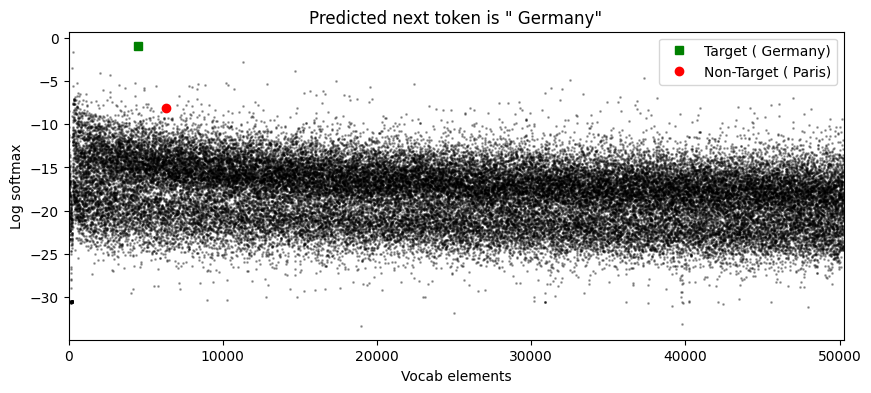

In [9]:
plt.figure(figsize=(10,4))

# all the log-sm values
plt.plot(np.log(results_clean),'k.',markersize=2,alpha=.3)

# the target and nontarget values
plt.plot(target_token_id,np.log(results_clean[target_token_id]),'gs',label=f'Target ({tokenizer.decode(target_token_id)})')
plt.plot(non_target_token_id,np.log(results_clean[non_target_token_id]),'ro',label=f'Non-Target ({tokenizer.decode(non_target_token_id)})')

# make the graph look pretty :D
plt.gca().set(xlabel='Vocab elements',ylabel='Log softmax',xlim=[0,model.config.vocab_size])
plt.title(f'Predicted next token is "{tokenizer.decode(np.argmax(results_clean))}"')
plt.legend()

plt.show()

# Laminar Profiling

In [10]:
# Loop over all layers and attention heads and store the softmax probabilities

# Initialize
results_zero = np.zeros((n_layer, n_head, 3)) # 0 for target tokens,1 for non-target tokens, 2 for storing the predicted token

# Set ablate to true
ablate = True

for layeri in range(n_layer):
  for headi in range(n_head):

    # Set the values for the hook function
    layer2change = layeri
    head2change = headi

    with torch.no_grad():
      outputs = model(tokens)

    # Calculate the softmax probabilities for the last logit token
    sm = F.softmax(outputs.logits[0,-1,:], dim=-1).detach().cpu().numpy()

    results_zero[layeri, headi, 0] = sm[target_token_id]
    results_zero[layeri, headi, 1] = sm[non_target_token_id]
    results_zero[layeri, headi, 2] = np.argmax(sm)


In [11]:
u, c = np.unique(results_zero[:,:,2], return_counts=True)
for ui, ci in zip(u, c):
  print(f'{ci}/{c.sum()} predicts "{tokenizer.decode(int(ui))}"')

1/144 predicts " the"
143/144 predicts " Germany"


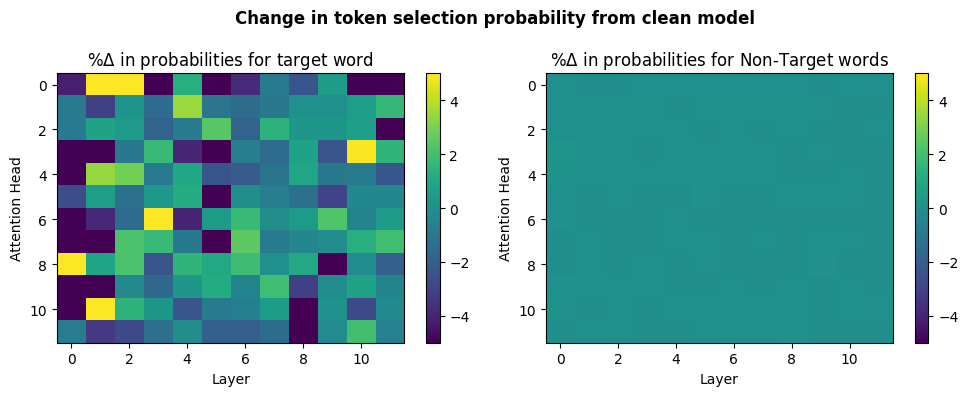

In [12]:
# VisuaLize
fig, axs = plt.subplots(1,2,figsize=(10,4))

# Plot target token probabilities
im0 = axs[0].imshow((results_zero[:,:,0].T - results_clean[target_token_id])*100, aspect='auto', cmap='viridis', vmin=-5, vmax=5)
axs[0].set(xlabel='Layer', ylabel='Attention Head', title='$\\%\\Delta$ in probabilities for target word')
fig.colorbar(im0, ax=axs[0], orientation='vertical')

# Plot non-target token probabilities
im1 = axs[1].imshow((results_zero[:,:,1].T - results_clean[non_target_token_id])*100, aspect='auto', cmap='viridis', vmin=-5, vmax=5)
axs[1].set(xlabel='Layer', ylabel='Attention Head', title='$\\%\\Delta$ in probabilities for Non-Target words')
fig.colorbar(im1, ax=axs[1], orientation='vertical')

fig.suptitle('Change in token selection probability from clean model', fontweight='bold')

plt.tight_layout()
plt.show()

In [13]:
# Loop over all layers and attention heads with the mean activations instead of ablation

# Initialize
results_mean = np.zeros((n_layer, n_head, 4)) # 0 for target tokens,1 for non-target tokens, 2 for storing the predicted token. 3 for capturing the mean

# Set ablate to true
ablate = False

for layeri in range(n_layer):
  for headi in range(n_head):

    # Set the values for the hook function
    layer2change = layeri
    head2change = headi

    with torch.no_grad():
      outputs = model(tokens)

    # Calculate the softmax probabilities for the last logit token
    sm = F.softmax(outputs.logits[0,-1,:], dim=-1).detach().cpu().numpy()

    results_mean[layeri, headi, 0] = sm[target_token_id]
    results_mean[layeri, headi, 1] = sm[non_target_token_id]
    results_mean[layeri, headi, 2] = np.argmax(sm)
    results_mean[layeri, headi, 3] = observed_head_mean


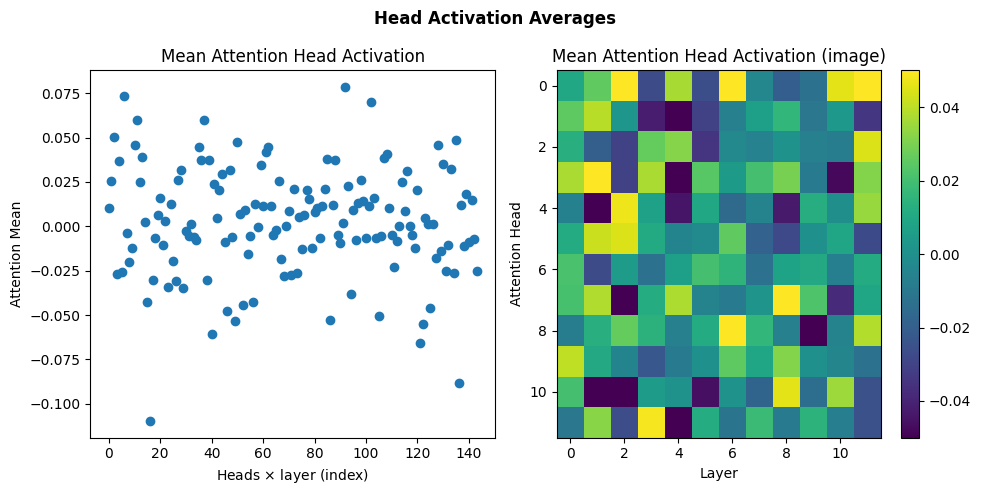

In [14]:
# Visualize
fig, axs = plt.subplots(1,2,figsize=(10,5))

axs[0].scatter(np.arange(n_layer * n_head), results_mean[:,:,3].T)
axs[0].set(xlabel='Heads $\\times$ layer (index)', ylabel='Attention Mean', title='Mean Attention Head Activation')

im = axs[1].imshow(results_mean[:,:,3].T,vmin=-.05, vmax=.05, cmap='viridis', aspect='auto')
axs[1].set(xlabel='Layer', ylabel='Attention Head', title='Mean Attention Head Activation (image)')
fig.colorbar(im, ax=axs[1], orientation='vertical')

fig.suptitle('Head Activation Averages', fontweight='bold')

plt.tight_layout()
plt.show()

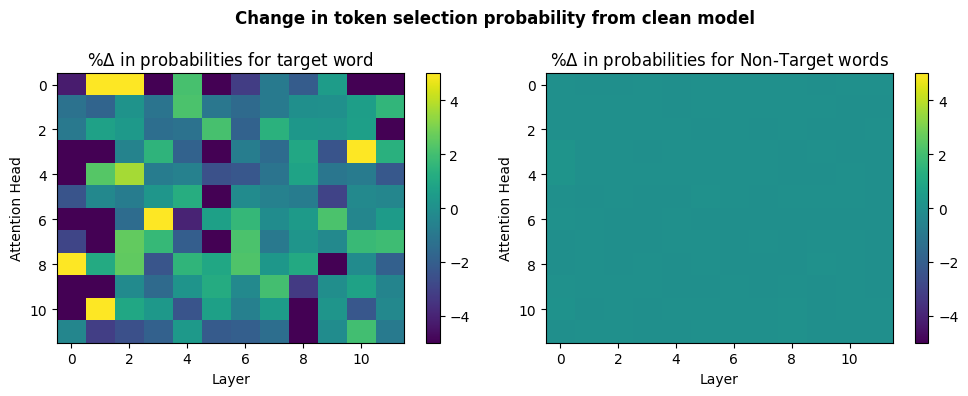

In [15]:
# VisuaLize
fig, axs = plt.subplots(1,2,figsize=(10,4))

# Plot target token probabilities
im0 = axs[0].imshow((results_mean[:,:,0].T - results_clean[target_token_id])*100, aspect='auto', cmap='viridis', vmin=-5, vmax=5)
axs[0].set(xlabel='Layer', ylabel='Attention Head', title='$\\%\\Delta$ in probabilities for target word')
fig.colorbar(im0, ax=axs[0], orientation='vertical')

# Plot non-target token probabilities
im1 = axs[1].imshow((results_mean[:,:,1].T - results_clean[non_target_token_id])*100, aspect='auto', cmap='viridis', vmin=-5, vmax=5)
axs[1].set(xlabel='Layer', ylabel='Attention Head', title='$\\%\\Delta$ in probabilities for Non-Target words')
fig.colorbar(im1, ax=axs[1], orientation='vertical')

fig.suptitle('Change in token selection probability from clean model', fontweight='bold')

plt.tight_layout()
plt.show()

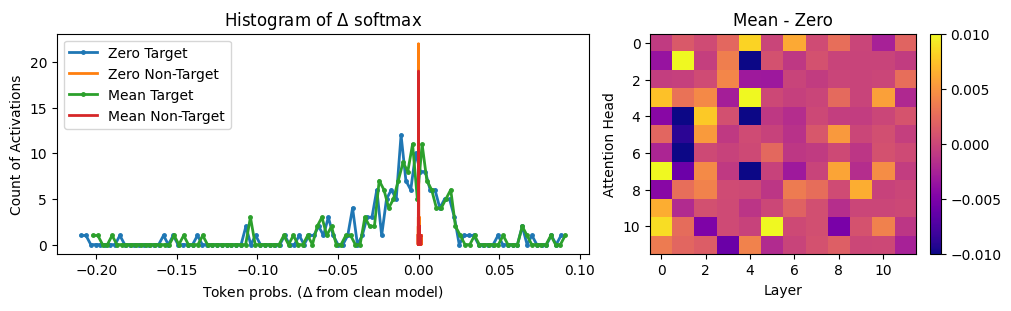

In [16]:
fig = plt.figure(figsize=(10,3), layout='constrained')
gs = GridSpec(1,3, figure=fig)

axs = [fig.add_subplot(gs[:2]), fig.add_subplot(gs[-1])]

# Specify number of bins
n_bins = 100

yy, xx = np.histogram(results_zero[:,:,0].flatten()-results_clean[target_token_id],n_bins)
axs[0].plot(xx[:-1], yy, '.-', lw=2, ms=5, label='Zero Target')

yy, xx = np.histogram(results_zero[:,:,1].flatten()-results_clean[non_target_token_id],n_bins)
axs[0].plot(xx[:-1], yy, '-', lw=2, label='Zero Non-Target')

yy, xx = np.histogram(results_mean[:,:,0].flatten()-results_clean[target_token_id],n_bins)
axs[0].plot(xx[:-1], yy, '.-', lw=2, ms=5, label='Mean Target')

yy, xx = np.histogram(results_mean[:,:,1].flatten()-results_clean[non_target_token_id],n_bins)
axs[0].plot(xx[:-1], yy, '-', lw=2, label='Mean Non-Target')

axs[0].set(xlabel='Token probs. ($\\Delta$ from clean model)', ylabel='Count of Activations', ylim=[-1,None], title='Histogram of $\\Delta$ softmax')
axs[0].legend(loc='upper left')

im = axs[1].imshow(results_mean[:,:,0].T - results_zero[:,:,0].T, vmin=-.01, vmax=.01, cmap=mpl.cm.plasma, aspect='auto')
axs[1].set(xlabel='Layer', ylabel='Attention Head', title='Mean - Zero')
fig.colorbar(im, ax=axs[1], orientation='vertical')


plt.show()